# Applying Regression Techniques to Fit Models on Real Datasets

## 📚 Learning Objectives

By completing this notebook, you will:
- Apply regression techniques to fit models on real datasets
- Implement linear and polynomial regression
- Evaluate regression models using appropriate metrics
- Handle real-world data preprocessing for regression

## 🔗 Prerequisites

- ✅ Understanding of regression concepts
- ✅ Understanding of gradient descent
- ✅ Python, NumPy, Pandas, scikit-learn knowledge

---

This notebook covers practical activities from **Course 03, Unit 3**:
- Applying regression techniques to fit models on real datasets

---

## Introduction

**Regression** is used to fit models that predict continuous values. This notebook demonstrates applying regression techniques to real-world datasets with proper preprocessing and evaluation.

## 📥 Inputs & 📤 Outputs

**Inputs:** What we use in this notebook

- Libraries and concepts as introduced in this notebook; see prerequisites and code comments.

**Outputs:** What you'll see when you run the cells

- Printed results, figures, and summaries as shown when you run the cells.

---

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.datasets import fetch_california_housing
import warnings
warnings.filterwarnings('ignore')
print("✅ Libraries imported!")
print("\nApplying Regression Techniques to Real Datasets")
print("=" * 60)


✅ Libraries imported!

Applying Regression Techniques to Real Datasets


## Part 1: Linear Regression on Real Dataset


In [2]:
import pandas as pd
print("=" * 60)
print("Part 1: Linear Regression on Real Dataset")
print("=" * 60)

# Load California Housing dataset (real-world dataset)
print("\nLoading California Housing dataset...")
try:
 housing = fetch_california_housing()
 X, y = housing.data, housing.target
 feature_names = housing.feature_names
 print(f"Dataset shape: {X.shape}")
 print(f"Features: {feature_names}")
 print(f"Target: Median house value (in $100,000s)")
except:
 # Fallback: create synthetic dataset with similar structure
 print("Using synthetic dataset (similar to California Housing)")
 np.random.seed(42)
 n_samples = 1000
 X = np.random.randn(n_samples, 8)
 y = 2.5 * X[:, 0] + 1.8 * X[:, 1] + 0.5 * X[:, 2] + np.random.randn(n_samples) * 0.5
 feature_names = [f'Feature_{i+1}' for i in range(8)]

# Create DataFrame for easier handling
df = pd.DataFrame(X, columns=feature_names)
df['target'] = y

print(f"\nFirst few rows:")
print(df.head())
# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"\nTraining samples: {X_train.shape[0]}")
print(f"Test samples: {X_test.shape[0]}")

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train linear regression
model = LinearRegression()
model.fit(X_train_scaled, y_train)

# Predictions
y_pred_train = model.predict(X_train_scaled)
y_pred_test = model.predict(X_test_scaled)

# Evaluate
train_mse = mean_squared_error(y_train, y_pred_train)
test_mse = mean_squared_error(y_test, y_pred_test)
train_r2 = r2_score(y_train, y_pred_train)
test_r2 = r2_score(y_test, y_pred_test)

print("\n" + "=" * 60)
print("Model Performance:")
print("=" * 60)
print(f"\nTraining Set:")
print(f" MSE: {train_mse:.4f}")
print(f" R²: {train_r2:.4f}")
print(f"\nTest Set:")
print(f" MSE: {test_mse:.4f}")
print(f" R²: {test_r2:.4f}")

print(f"\nCoefficients:")
for name, coef in zip(feature_names, model.coef_):
 print(f" {name}: {coef:.4f}")
print(f" Intercept: {model.intercept_:.4f}")

print("\n✅ Linear regression trained on real dataset!")

Part 1: Linear Regression on Real Dataset

Loading California Housing dataset...
Dataset shape: (20640, 8)
Features: ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']
Target: Median house value (in $100,000s)

First few rows:
   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  target  
0    -122.23   4.526  
1    -122.22   3.585  
2    -122.24   3.521  
3    -122.25   3.413  
4    -122.25   3.422  

Training samples: 16512
Test samples: 4128

Model Performance:

Training Set:
 MSE: 0.5179
 R²: 0.6126

Test Set:
 MSE: 0.5559
 R

## Part 2: Polynomial Regression

Linear regression assumes a straight-line relationship. **Polynomial regression** adds powers of a feature (x², x³, …) so the model can bend.

Here we fit degrees 1-4 using a **single feature** (median income) so the fitted curves can be visualized. Watch two things in the output:
- **Train vs test R²**: if train keeps improving while test stalls or drops, the extra polynomial terms are overfitting.
- **Diminishing returns**: with one feature, the higher-degree terms add only a little — most of the signal in this dataset lives in the *other* features, not in a curvier income relationship.



Part 2: Polynomial Regression

Degree 1:
 Train R²: 0.4770
 Test R²: 0.4589

Degree 2:
 Train R²: 0.4816
 Test R²: 0.4633

Degree 3:
 Train R²: 0.4908
 Test R²: 0.4671

Degree 4:
 Train R²: 0.4909
 Test R²: 0.4673


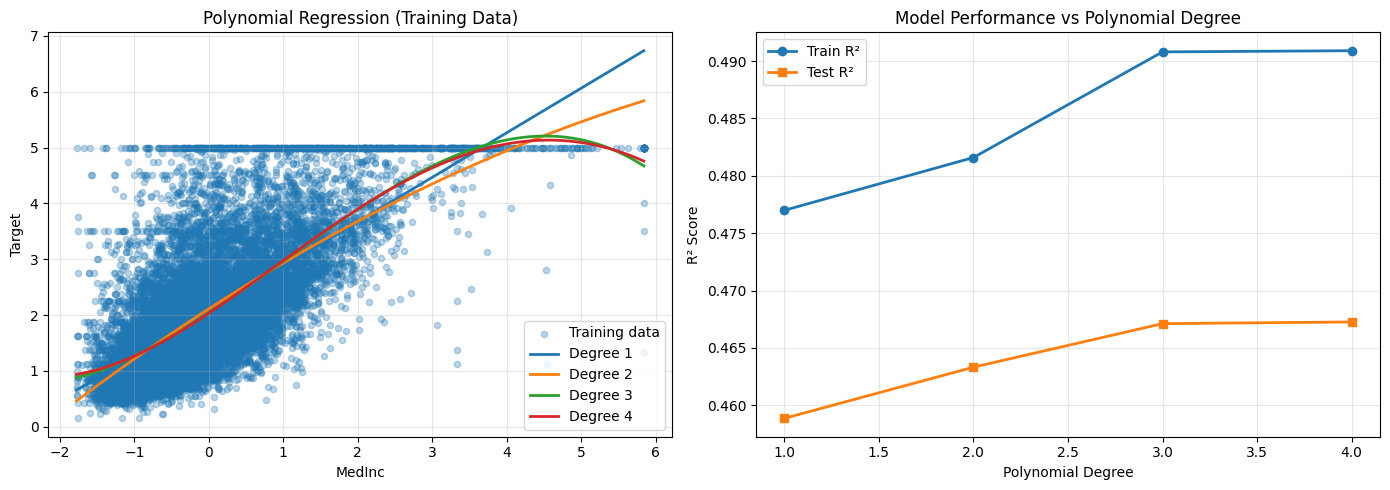


✅ Polynomial regression applied!


In [3]:
print("\n" + "=" * 60)
print("Part 2: Polynomial Regression")
print("=" * 60)

# Use single feature for visualization
X_single = X_train_scaled[:, 0:1]
X_test_single = X_test_scaled[:, 0:1]

# Polynomial features
degrees = [1, 2, 3, 4]
results = []

for degree in degrees:
 poly = PolynomialFeatures(degree=degree)
 X_train_poly = poly.fit_transform(X_single)
 X_test_poly = poly.transform(X_test_single)
 
 model_poly = LinearRegression()
 model_poly.fit(X_train_poly, y_train)
 
 y_pred_train = model_poly.predict(X_train_poly)
 y_pred_test = model_poly.predict(X_test_poly)
 
 train_r2 = r2_score(y_train, y_pred_train)
 test_r2 = r2_score(y_test, y_pred_test)
 
 results.append({
 'degree': degree, 'train_r2': train_r2,
 'test_r2': test_r2,
 'model': model_poly,
 'poly': poly
 })
 
 print(f"\nDegree {degree}:")
 print(f" Train R²: {train_r2:.4f}")
 print(f" Test R²: {test_r2:.4f}")

# Visualize
plt.figure(figsize=(14, 5))
plt.subplot(1, 2, 1)
plt.scatter(X_single, y_train, alpha=0.3, label='Training data', s=20)
x_plot = np.linspace(X_single.min(), X_single.max(), 100).reshape(-1, 1)
for r in results:
 x_plot_poly = r['poly'].transform(x_plot)
 y_plot = r['model'].predict(x_plot_poly)
 plt.plot(x_plot, y_plot, label=f'Degree {r["degree"]}', linewidth=2)
plt.xlabel(feature_names[0])
plt.ylabel('Target')
plt.title('Polynomial Regression (Training Data)')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
degrees_list = [r['degree'] for r in results]
train_r2_list = [r['train_r2'] for r in results]
test_r2_list = [r['test_r2'] for r in results]
plt.plot(degrees_list, train_r2_list, 'o-', label='Train R²', linewidth=2)
plt.plot(degrees_list, test_r2_list, 's-', label='Test R²', linewidth=2)
plt.xlabel('Polynomial Degree')
plt.ylabel('R² Score')
plt.title('Model Performance vs Polynomial Degree')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n✅ Polynomial regression applied!")

## Part 3: Regularized Regression (Ridge and Lasso)

**Regularization** adds a penalty on large weights to the loss, controlled by the strength α:
- **Ridge** (L2 penalty) shrinks all weights smoothly toward zero.
- **Lasso** (L1 penalty) can drive weights *exactly* to zero — it performs feature selection.

How to read the sweep below:
- **Ridge barely moves** across this α range — with 8 informative, scaled features and ~16k training samples, the unregularized fit is already stable, so mild shrinkage changes little.
- **Lasso collapses at large α**: once the penalty dominates, it zeroes out *every* coefficient. The model then predicts a constant (the mean of the training targets), and test R² falls to ≈ 0 — the score of always guessing the mean. It can even go slightly *negative*, because the training mean is not exactly the test mean.

**Takeaway**: regularization strength is a dial, not a free win — too much destroys the model. Tune α on validation data.



Part 3: Regularized Regression (Ridge and Lasso)



Ridge Regression Results:
 Alpha  0.001: R² = 0.5758
 Alpha  0.010: R² = 0.5758
 Alpha  0.100: R² = 0.5758
 Alpha  1.000: R² = 0.5758
 Alpha 10.000: R² = 0.5761
 Alpha 100.000: R² = 0.5778

Lasso Regression Results:
 Alpha  0.001: R² = 0.5769
 Alpha  0.010: R² = 0.5816
 Alpha  0.100: R² = 0.4814
 Alpha  1.000: R² = -0.0002
 Alpha 10.000: R² = -0.0002
 Alpha 100.000: R² = -0.0002


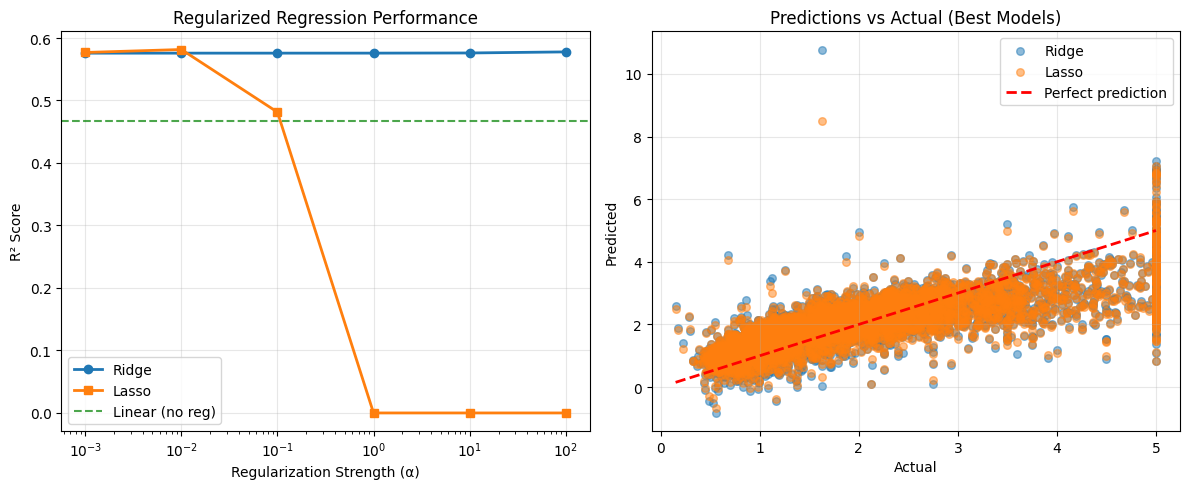


✅ Regularized regression applied!


In [4]:
print("\n" + "=" * 60)
print("Part 3: Regularized Regression (Ridge and Lasso)")
print("=" * 60)

# Compare Ridge and Lasso
alpha_values = [0.001, 0.01, 0.1, 1.0, 10.0, 100.0]

ridge_results = []
lasso_results = []

for alpha in alpha_values:
 # Ridge
 ridge = Ridge(alpha=alpha)
 ridge.fit(X_train_scaled, y_train)
 y_pred_ridge = ridge.predict(X_test_scaled)
 ridge_r2 = r2_score(y_test, y_pred_ridge)
 ridge_results.append({'alpha': alpha, 'r2': ridge_r2, 'model': ridge})
 
 # Lasso
 lasso = Lasso(alpha=alpha, max_iter=2000)
 lasso.fit(X_train_scaled, y_train)
 y_pred_lasso = lasso.predict(X_test_scaled)
 lasso_r2 = r2_score(y_test, y_pred_lasso)
 lasso_results.append({'alpha': alpha, 'r2': lasso_r2, 'model': lasso})

print("\nRidge Regression Results:")
for r in ridge_results:
 print(f" Alpha {r['alpha']:6.3f}: R² = {r['r2']:.4f}")

print("\nLasso Regression Results:")
for r in lasso_results:
 print(f" Alpha {r['alpha']:6.3f}: R² = {r['r2']:.4f}")

# Visualize
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
ridge_alphas = [r['alpha'] for r in ridge_results]
ridge_r2s = [r['r2'] for r in ridge_results]
lasso_alphas = [r['alpha'] for r in lasso_results]
lasso_r2s = [r['r2'] for r in lasso_results]
plt.semilogx(ridge_alphas, ridge_r2s, 'o-', label='Ridge', linewidth=2)
plt.semilogx(lasso_alphas, lasso_r2s, 's-', label='Lasso', linewidth=2)
plt.axhline(y=test_r2, color='g', linestyle='--', label='Linear (no reg)', alpha=0.7)
plt.xlabel('Regularization Strength (α)')
plt.ylabel('R² Score')
plt.title('Regularized Regression Performance')
plt.legend()
plt.grid(True, alpha=0.3)

# Compare predictions
best_ridge = max(ridge_results, key=lambda x: x['r2'])
best_lasso = max(lasso_results, key=lambda x: x['r2'])

plt.subplot(1, 2, 2)
y_pred_ridge_best = best_ridge['model'].predict(X_test_scaled)
y_pred_lasso_best = best_lasso['model'].predict(X_test_scaled)
plt.scatter(y_test, y_pred_ridge_best, alpha=0.5, label='Ridge', s=30)
plt.scatter(y_test, y_pred_lasso_best, alpha=0.5, label='Lasso', s=30)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', linewidth=2, label='Perfect prediction')
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.title('Predictions vs Actual (Best Models)')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n✅ Regularized regression applied!")

## Summary

### Key Concepts:
1. **Linear Regression**: Fits a linear model to data
2. **Polynomial Regression**: Captures non-linear relationships
3. **Regularized Regression**: Prevents overfitting (Ridge, Lasso)
4. **Model Evaluation**: Use R², MSE, MAE metrics
5. **Data Preprocessing**: Scaling is important for regression

### Best Practices:
- Always split data into train/test sets
- Scale features before training
- Use regularization to prevent overfitting
- Evaluate on test set, not training set
- Visualize results to understand model behavior

### Applications:
- House price prediction
- Sales forecasting
- Temperature prediction
- Any continuous value prediction

**Reference:** Course 03, Unit 3: "Optimization and Statistical Foundations" - Regression on real datasets practical content